# LOD MLP Training Pipeline
**COMP 432 — Adaptive LOD Control**

Pipeline:
1. Load `training_data_labeled.csv`
2. Select and normalize features
3. Split train/validation
4. Define MLP (64 -> 32 -> 1, Sigmoid output)
5. Train with MSE loss + Adam
6. Evaluate and plot
7. Export to ONNX for Unity Sentis

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib
import os
print(os.path.exists('/content/drive/MyDrive/Concordia/COMP432/Project'))
print(os.listdir('/content/drive/MyDrive/Concordia/COMP432/Project'))

from google.colab import drive
drive.mount('/content/drive')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

True
['training_data_labeled.csv', '.ipynb', 'train_lod_mlp.ipynb', 'feature_scaler.pkl']
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch version: 2.10.0+cpu
CUDA available: False
Using device: cpu


## 1. Configuration

In [ ]:
# -----------------------------------------
# CONFIG
# -----------------------------------------
INPUT_FILE   = '/content/drive/MyDrive/Concordia/COMP432/Project/training_data_labeled.csv'
MODEL_OUT    = '/content/drive/MyDrive/Concordia/COMP432/Project/lod_mlp.onnx'
SCALER_OUT   = '/content/drive/MyDrive/Concordia/COMP432/Project/feature_scaler.pkl'

FEATURE_COLS = [
    'cpu_frame_time_ms',
    'gpu_frame_time_ms',
    'triangle_count',
    'camera_velocity',
    'camera_angular_velocity',
    'visible_renderer_count',
    'draw_call_estimate',
    'frame_headroom_ms',
    'screen_coverage',
    'lod_bias_current',
]

TARGET_COL   = 'target_lod_bias'

# MLP architecture (from project docs)
HIDDEN1      = 64
HIDDEN2      = 32

# Training
BATCH_SIZE   = 512
EPOCHS       = 50
LR           = 1e-3
VAL_SPLIT    = 0.2
SEED         = 42

# LOD bias range for output denormalization
BIAS_MIN     = 0.25
BIAS_MAX     = 2.0
# -----------------------------------------

torch.manual_seed(SEED)
np.random.seed(SEED)

## 2. Load and Inspect Data

In [ ]:
df = pd.read_csv(INPUT_FILE)
print(f'Loaded {len(df)} rows, {len(df.columns)} columns')
print(f'\nTarget distribution:')
print(df[TARGET_COL].value_counts().sort_index())
print(f'\nFeature stats:')
df[FEATURE_COLS].describe().round(3)

Loaded 135000 rows, 22 columns

Target distribution:
target_lod_bias
0.25    70177
1.00    56997
2.00     7826
Name: count, dtype: int64

Feature stats:


,cpu_frame_time_ms,gpu_frame_time_ms,triangle_count,camera_velocity,camera_angular_velocity,visible_renderer_count,draw_call_estimate,frame_headroom_ms,screen_coverage,lod_bias_current
count,135000.000,135000.000,135000.000,135000.000,135000.000,135000.000,135000.000,135000.000,135000.000,135000.000
mean,60.551,10.729,404628.373,3.796,3.423,10910.342,3136.559,-43.951,0.007,1.083
std,26.281,3.386,254887.946,3.114,14.390,8532.881,2124.068,26.281,0.009,0.717
min,10.741,0.016,45111.000,0.000,0.000,0.000,184.000,-2207.568,0.000,0.250
25%,42.417,9.000,200843.500,0.500,0.000,4089.000,1424.000,-50.737,0.001,0.250
50%,58.284,10.913,353521.000,3.000,0.000,9281.000,2756.000,-41.683,0.003,1.000
75%,67.337,12.822,570980.750,8.000,0.000,14841.250,4419.000,-25.817,0.008,2.000
max,2224.168,113.009,1394878.000,8.001,266.772,32793.000,10323.000,5.859,0.064,2.000


## 3. Preprocessing

In [ ]:
# Drop rows with NaN in features or target
df = df.dropna(subset=FEATURE_COLS + [TARGET_COL])
print(f'Rows after dropna: {len(df)}')

X = df[FEATURE_COLS].values.astype(np.float32)
y_raw = df[TARGET_COL].values.astype(np.float32)

# Normalize target to [0, 1] for Sigmoid output
y = (y_raw - BIAS_MIN) / (BIAS_MAX - BIAS_MIN)
print(f'\nNormalized target range: [{y.min():.3f}, {y.max():.3f}]')

# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X = scaler.fit_transform(X)
joblib.dump(scaler, SCALER_OUT)
print(f'Scaler saved to {SCALER_OUT}')

# Split off 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)

# Split remaining 80% into 80% train / 20% val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, shuffle=True
)

print(f'\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Rows after dropna: 135000

Normalized target range: [0.000, 1.000]
Scaler saved to /content/drive/MyDrive/Concordia/COMP432/Project/feature_scaler.pkl

Train: 86400 | Val: 21600 | Test: 27000


## 4. Dataset and DataLoader

In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t,   y_val_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 169 | Val batches: 43


## 5. Model Definition
Architecture from project docs: Input -> 64 (ReLU) -> 32 (ReLU) -> 1 (Sigmoid)

In [ ]:
class LODPredictor(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32):
        super(LODPredictor, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)


INPUT_DIM = X_train.shape[1]
model     = LODPredictor(INPUT_DIM, HIDDEN1, HIDDEN2).to(DEVICE)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params}')

LODPredictor(
  (layers): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

Total parameters: 2817


## 6. Training

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

train_losses = []
val_losses   = []

for epoch in range(EPOCHS):
    # --- train ---
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)

    # --- validate ---
    model.eval()
    with torch.no_grad():
        val_batch_losses = []
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            preds = model(X_batch)
            val_batch_losses.append(criterion(preds, y_batch).item())
        val_loss = np.mean(val_batch_losses)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}')

print('Training complete.')

# --- test ---
model.eval()
with torch.no_grad():
    X_test_t  = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
    y_test_t  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(DEVICE)
    test_preds = model(X_test_t)
    test_loss  = criterion(test_preds, y_test_t).item()

test_preds_bias  = test_preds.cpu().numpy().flatten() * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
test_target_bias = y_test * (BIAS_MAX - BIAS_MIN) + BIAS_MIN

test_mae  = np.mean(np.abs(test_preds_bias - test_target_bias))
test_rmse = np.sqrt(np.mean((test_preds_bias - test_target_bias) ** 2))

print(f'\nTest MSE  (normalized): {test_loss:.6f}')
print(f'Test MAE  (bias units): {test_mae:.4f}')
print(f'Test RMSE (bias units): {test_rmse:.4f}')

Epoch   5/50 | Train MSE: 0.040591 | Val MSE: 0.040197
Epoch  10/50 | Train MSE: 0.030888 | Val MSE: 0.030070
Epoch  15/50 | Train MSE: 0.023948 | Val MSE: 0.023619
Epoch  20/50 | Train MSE: 0.020650 | Val MSE: 0.020615
Epoch  25/50 | Train MSE: 0.018725 | Val MSE: 0.018715
Epoch  30/50 | Train MSE: 0.017468 | Val MSE: 0.017712
Epoch  35/50 | Train MSE: 0.016423 | Val MSE: 0.016795
Epoch  40/50 | Train MSE: 0.015750 | Val MSE: 0.016186
Epoch  45/50 | Train MSE: 0.015077 | Val MSE: 0.015887
Epoch  50/50 | Train MSE: 0.014535 | Val MSE: 0.015408
Training complete.

Test MSE  (normalized): 0.015771
Test MAE  (bias units): 0.1178
Test RMSE (bias units): 0.2198


## 7. Loss Curves

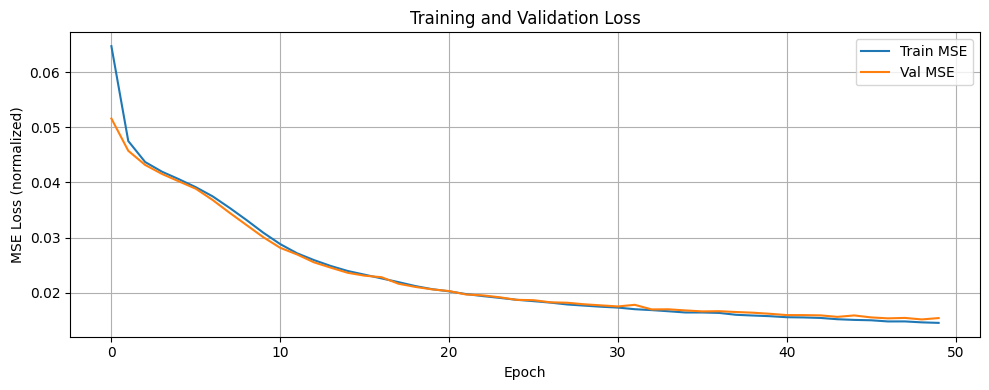

Final train MSE: 0.014535
Final val   MSE: 0.015408


In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train MSE')
plt.plot(val_losses,   label='Val MSE')
plt.axhline(y=test_loss, color='red', linestyle='--', label=f'Test MSE = {test_loss:.6f}')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (normalized)')
plt.title('Training, Validation and Test Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

print(f'Final Train MSE : {train_losses[-1]:.6f}')
print(f'Final Val   MSE : {val_losses[-1]:.6f}')
print(f'Test        MSE : {test_loss:.6f}')
print(f'Test        MAE : {test_mae:.4f} (bias units)')
print(f'Test        RMSE: {test_rmse:.4f} (bias units)')

## 8. Evaluation — Denormalized Predictions

1.   List item
2.   List item



Val  MAE: 0.1162 | Val  RMSE: 0.2167
Test MAE: 0.1178 | Test RMSE: 0.2198


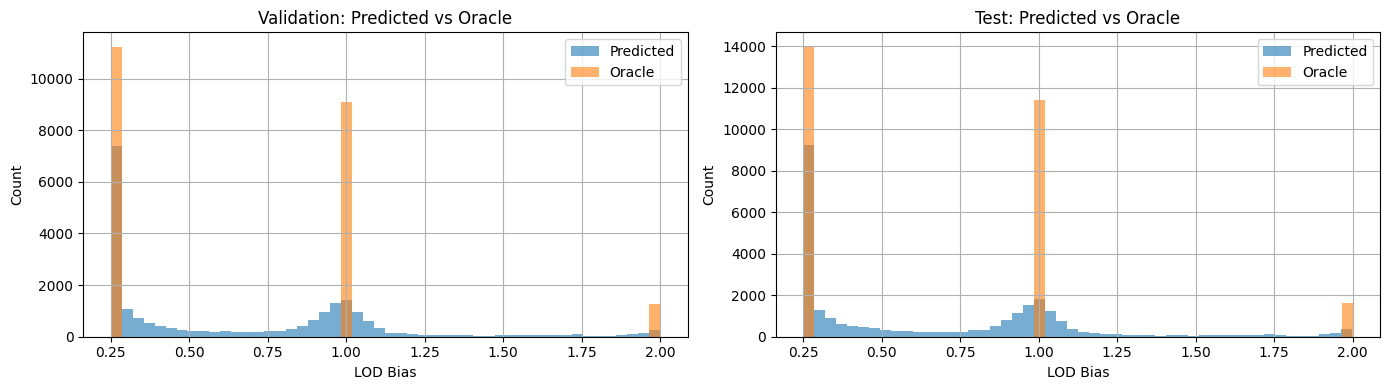

In [ ]:
model.eval()
with torch.no_grad():
    preds_norm      = model(X_val_t.to(DEVICE)).cpu().numpy().flatten()
    test_preds_norm = model(torch.tensor(X_test, dtype=torch.float32).to(DEVICE)).cpu().numpy().flatten()

# Denormalize
preds_bias       = preds_norm      * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
test_preds_bias  = test_preds_norm * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
target_bias      = y_val           * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
test_target_bias = y_test          * (BIAS_MAX - BIAS_MIN) + BIAS_MIN

# Metrics
val_mae  = np.mean(np.abs(preds_bias  - target_bias))
val_rmse = np.sqrt(np.mean((preds_bias  - target_bias) ** 2))
t_mae    = np.mean(np.abs(test_preds_bias - test_target_bias))
t_rmse   = np.sqrt(np.mean((test_preds_bias - test_target_bias) ** 2))

print(f'Val  MAE: {val_mae:.4f} | Val  RMSE: {val_rmse:.4f}')
print(f'Test MAE: {t_mae:.4f} | Test RMSE: {t_rmse:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(preds_bias,  bins=50, alpha=0.6, label='Predicted')
axes[0].hist(target_bias, bins=50, alpha=0.6, label='Oracle')
axes[0].set_title('Validation: Predicted vs Oracle')
axes[0].set_xlabel('LOD Bias')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True)

axes[1].hist(test_preds_bias,  bins=50, alpha=0.6, label='Predicted')
axes[1].hist(test_target_bias, bins=50, alpha=0.6, label='Oracle')
axes[1].set_title('Test: Predicted vs Oracle')
axes[1].set_xlabel('LOD Bias')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('prediction_distribution.png', dpi=150)
plt.show()

## 9. Export to ONNX for Unity Sentis

In [ ]:
!pip install onnxscript onnx

model.eval()
model.cpu()

dummy_input = torch.zeros(1, INPUT_DIM, dtype=torch.float32)

torch.onnx.export(
    model,
    dummy_input,
    MODEL_OUT,
    export_params=True,
    opset_version=11,
    input_names=['features'],
    output_names=['lod_bias_normalized'],
    dynamic_axes={
        'features':           {0: 'batch_size'},
        'lod_bias_normalized': {0: 'batch_size'}
    }
)

size_kb = os.path.getsize(MODEL_OUT) / 1024
print(f'ONNX model saved to {MODEL_OUT} ({size_kb:.1f} KB)')
print(f'Input dim: {INPUT_DIM} features')
print(f'Output: normalized bias in [0,1] -> denormalize with BIAS_MIN={BIAS_MIN}, BIAS_MAX={BIAS_MAX}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 13.9 MB/s eta 0:00:00


/tmp/ipykernel_1398/4237625010.py:8: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0304 20:26:35.117000 1398 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `LODPredictor([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `LODPredictor([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX model saved to /content/drive/MyDrive/Concordia/COMP432/Project/lod_mlp.onnx (9.1 KB)
Input dim: 10 features
Output: normalized bias in [0,1] -> denormalize with BIAS_MIN=0.25, BIAS_MAX=2.0


## 10. Unity Sentis Integration Notes

In `NeuralLODController.cs`, denormalize the output:

```csharp
float normalizedBias = output[0];  // Sigmoid output in [0,1]
float predictedBias  = normalizedBias * (BIAS_MAX - BIAS_MIN) + BIAS_MIN;
// BIAS_MIN = 0.25f, BIAS_MAX = 2.0f
```

Feature order for the input tensor must match `FEATURE_COLS` exactly:
```
0  cpu_frame_time_ms
1  gpu_frame_time_ms
2  triangle_count
3  camera_velocity
4  camera_angular_velocity
5  visible_renderer_count
6  draw_call_estimate
7  frame_headroom_ms
8  screen_coverage
9  lod_bias_current
```

Apply scaler mean/std from `feature_scaler.pkl` to each feature before inference:
```csharp
float[] scalerMean = { /* from scaler.mean_ */ };
float[] scalerStd  = { /* from scaler.scale_ */ };
for (int i = 0; i < features.Length; i++)
    features[i] = (features[i] - scalerMean[i]) / scalerStd[i];
```